In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\spscientist\students-performance-in-exams\versions\1


In [22]:
import os 
os.listdir(path)


['StudentsPerformance.csv']

In [23]:
import pandas as pd
#df = pd.read_csv(path+"/StudentsPerformance.csv")
df = pd.read_csv("./data/stud.csv")

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [27]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [30]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [31]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [37]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
numerical_features = [feature for feature in df.columns if df[feature].dtype == 'int64']

In [40]:
print(categorical_features)
print(numerical_features)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
['math_score', 'reading_score', 'writing_score']


In [45]:
for feature in categorical_features:
    print(df[feature].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
<StringArray>
['none', 'completed']
Length: 2, dtype: str


In [46]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [47]:
df['average_score'] = df['total_score']/3

In [48]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


<Axes: xlabel='average_score', ylabel='Count'>

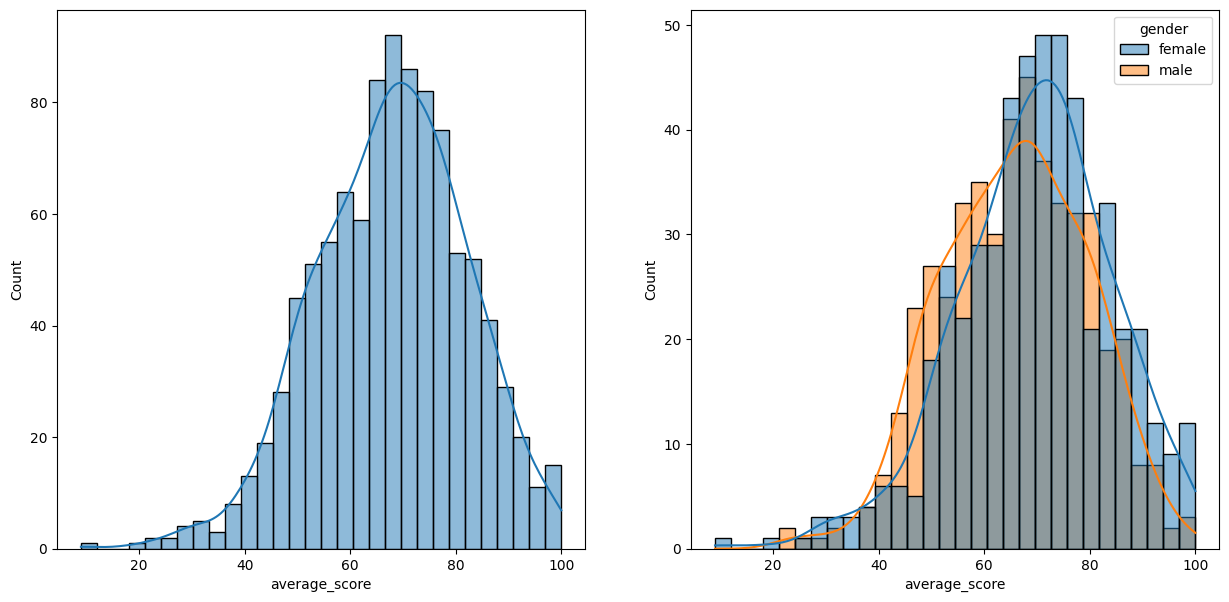

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df,x='average_score',bins=30,ax=axs[0],kde=True)
sns.histplot(data=df,x='average_score',bins=30,hue='gender',ax=axs[1],kde=True)

<Axes: xlabel='total_score', ylabel='Count'>

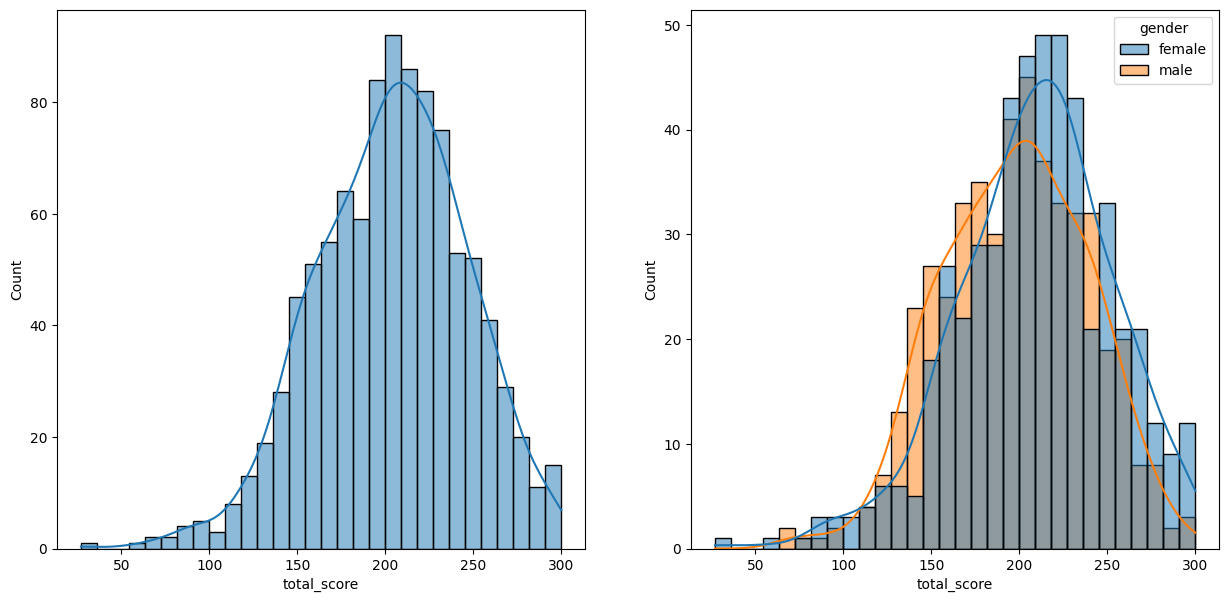

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df,x='total_score',bins=30,ax=axs[0],kde=True)
sns.histplot(data=df,x='total_score',bins=30,hue='gender',ax=axs[1],kde=True)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race_ethnicity               1000 non-null   str    
 2   parental_level_of_education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test_preparation_course      1000 non-null   str    
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
dtypes: float64(1), int64(4), str(5)
memory usage: 78.3 KB


<Axes: xlabel='total_score', ylabel='Count'>

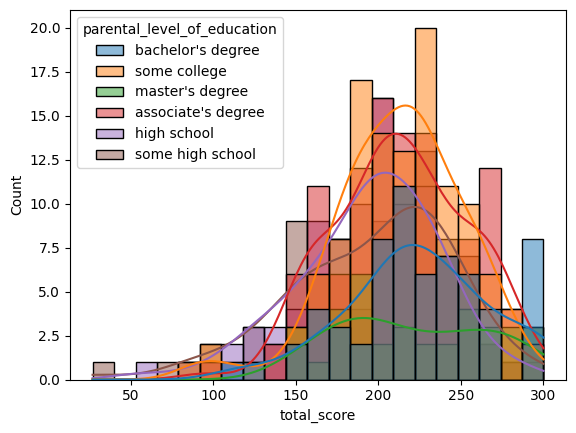

In [62]:
sns.histplot(x='total_score',data=df[df['gender']=='female'],hue='parental_level_of_education',kde=True)

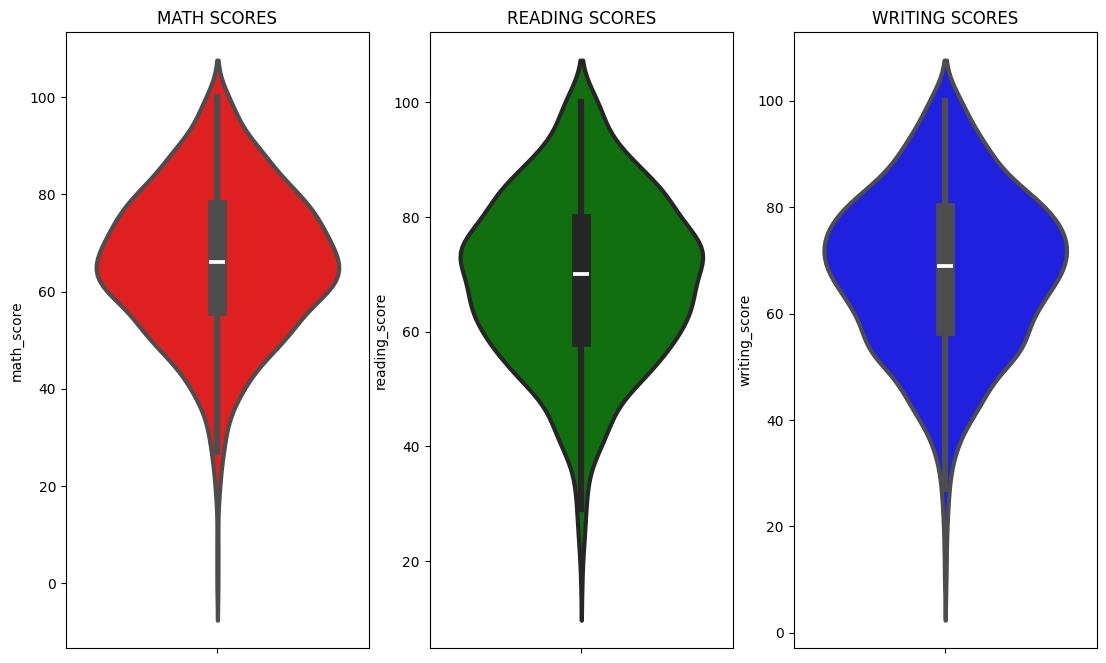

In [64]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

In [66]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

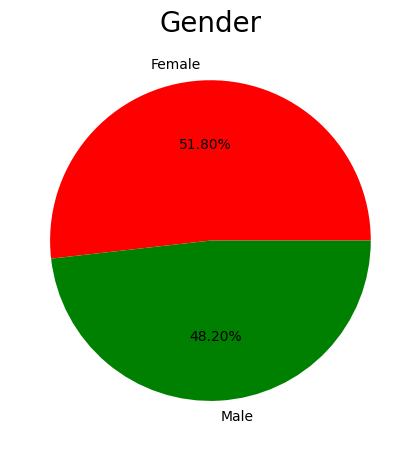

In [93]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')


([<matplotlib.patches.Wedge at 0x21b50b25590>,
 [Text(-0.07064828115219943, 1.2480019312365827, 'Male'),
  Text(0.07064809270914973, -1.2480019419041621, 'Female')],
 [Text(-0.04238896869131965, 0.7488011587419495, '51.8%'),
  Text(0.04238885562548984, -0.7488011651424973, '48.2%')])

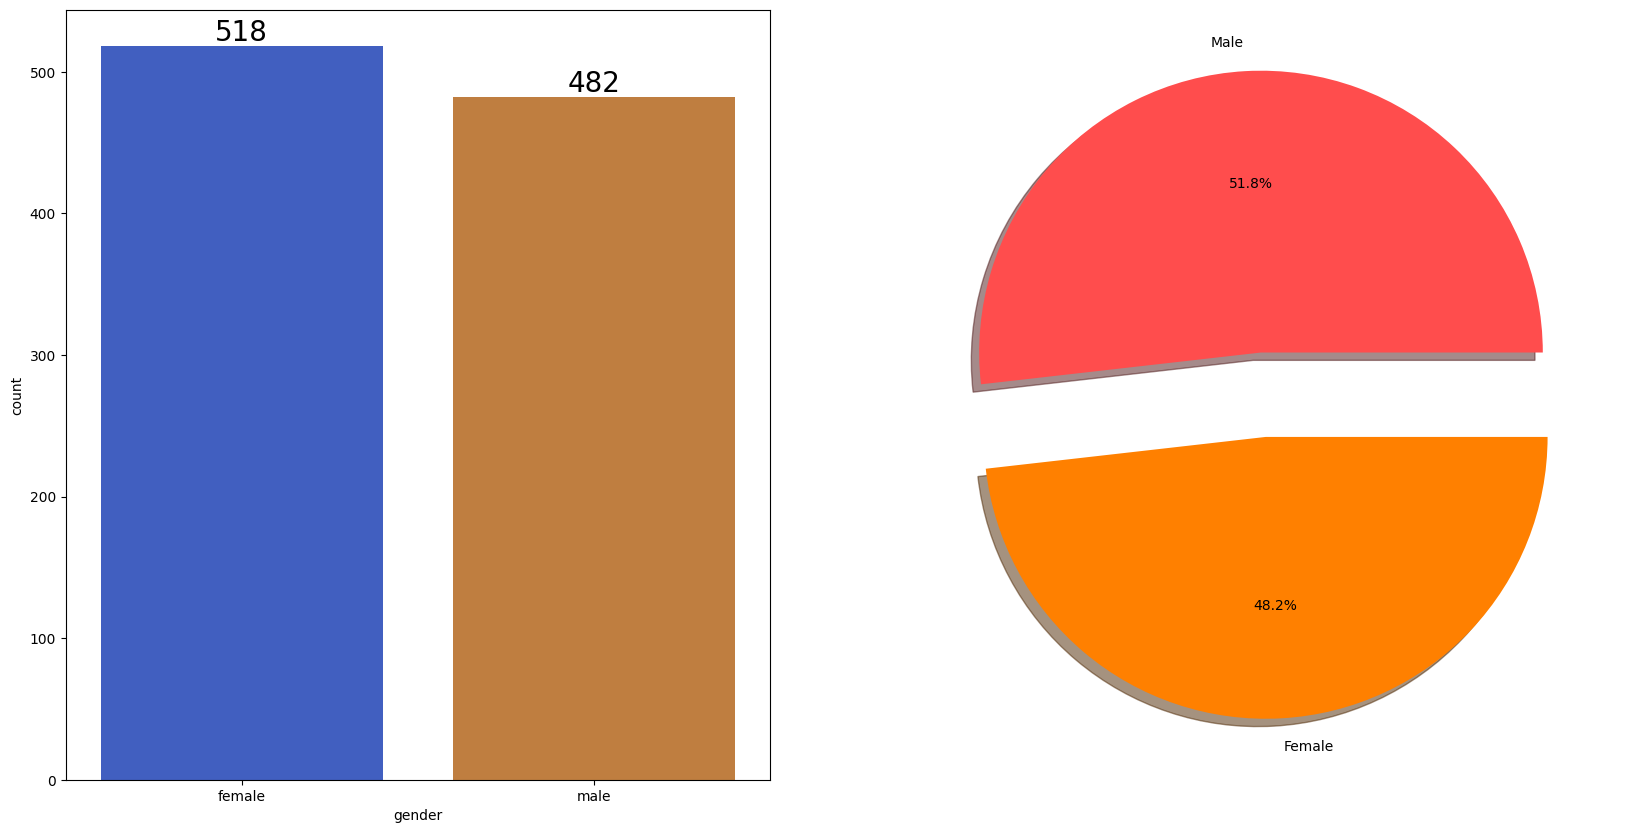

In [106]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.5)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0.15,0.15],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])

In [ ]:
gender_group = df.groupby('gender')
gender_group['math_score'].mean()


np.float64(68.72821576763485)

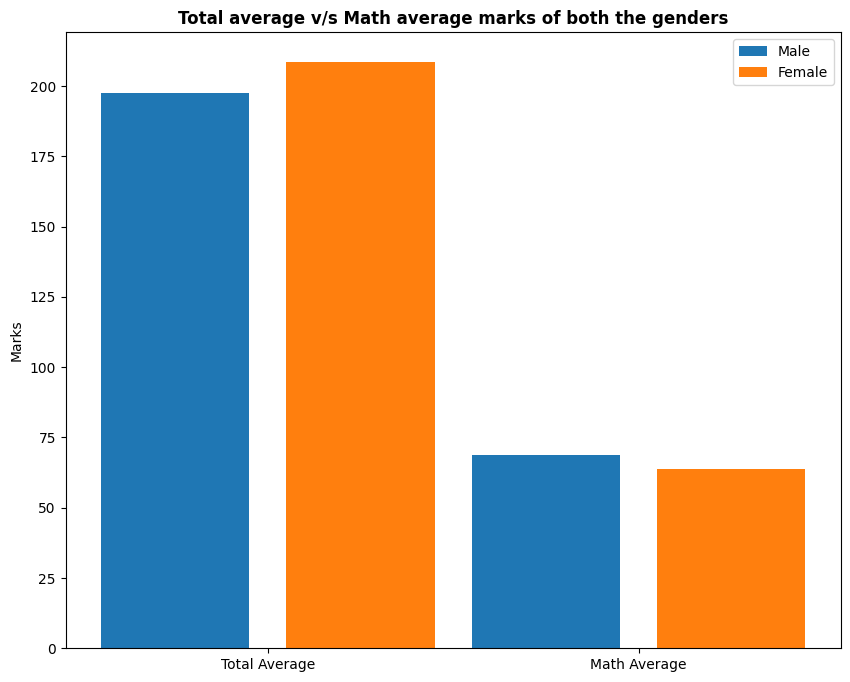

In [147]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['total_score'].mean().female, gender_group['math_score'].mean().female]
male_scores = [gender_group['total_score'].mean().male, gender_group['math_score'].mean().male]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.25, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.25, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

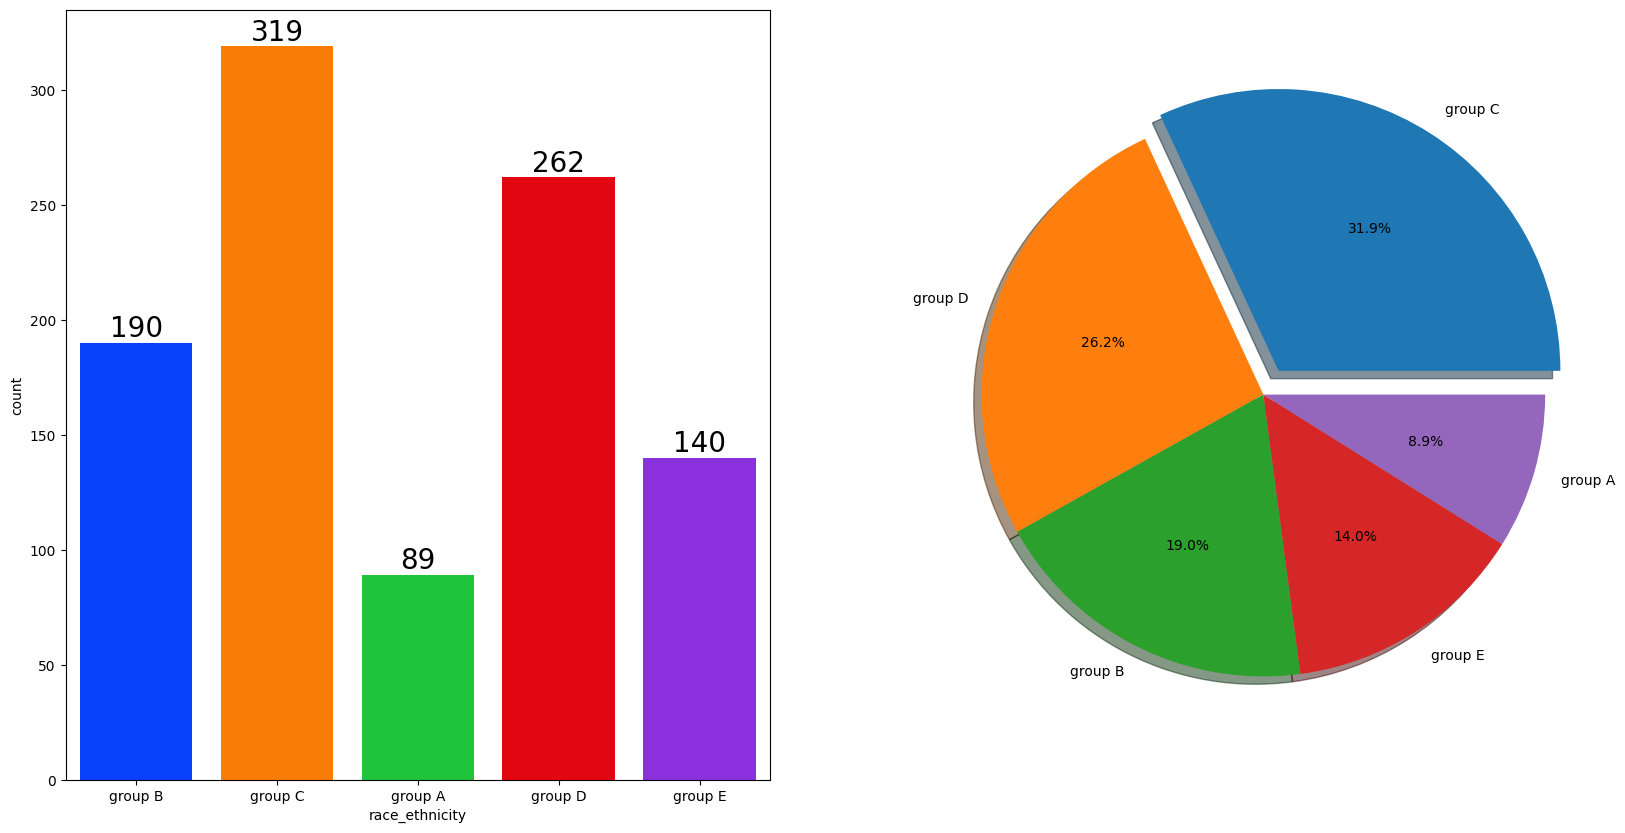

In [152]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

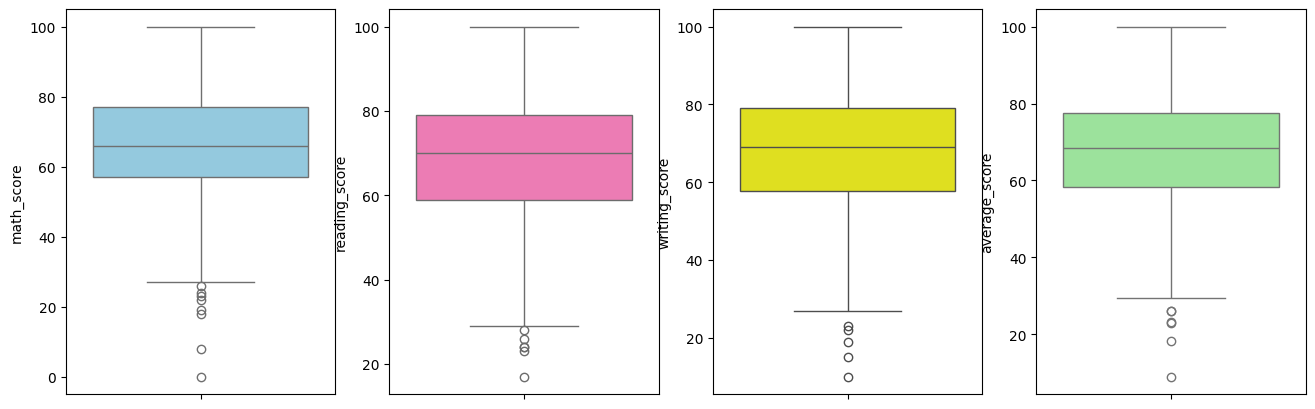

In [156]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

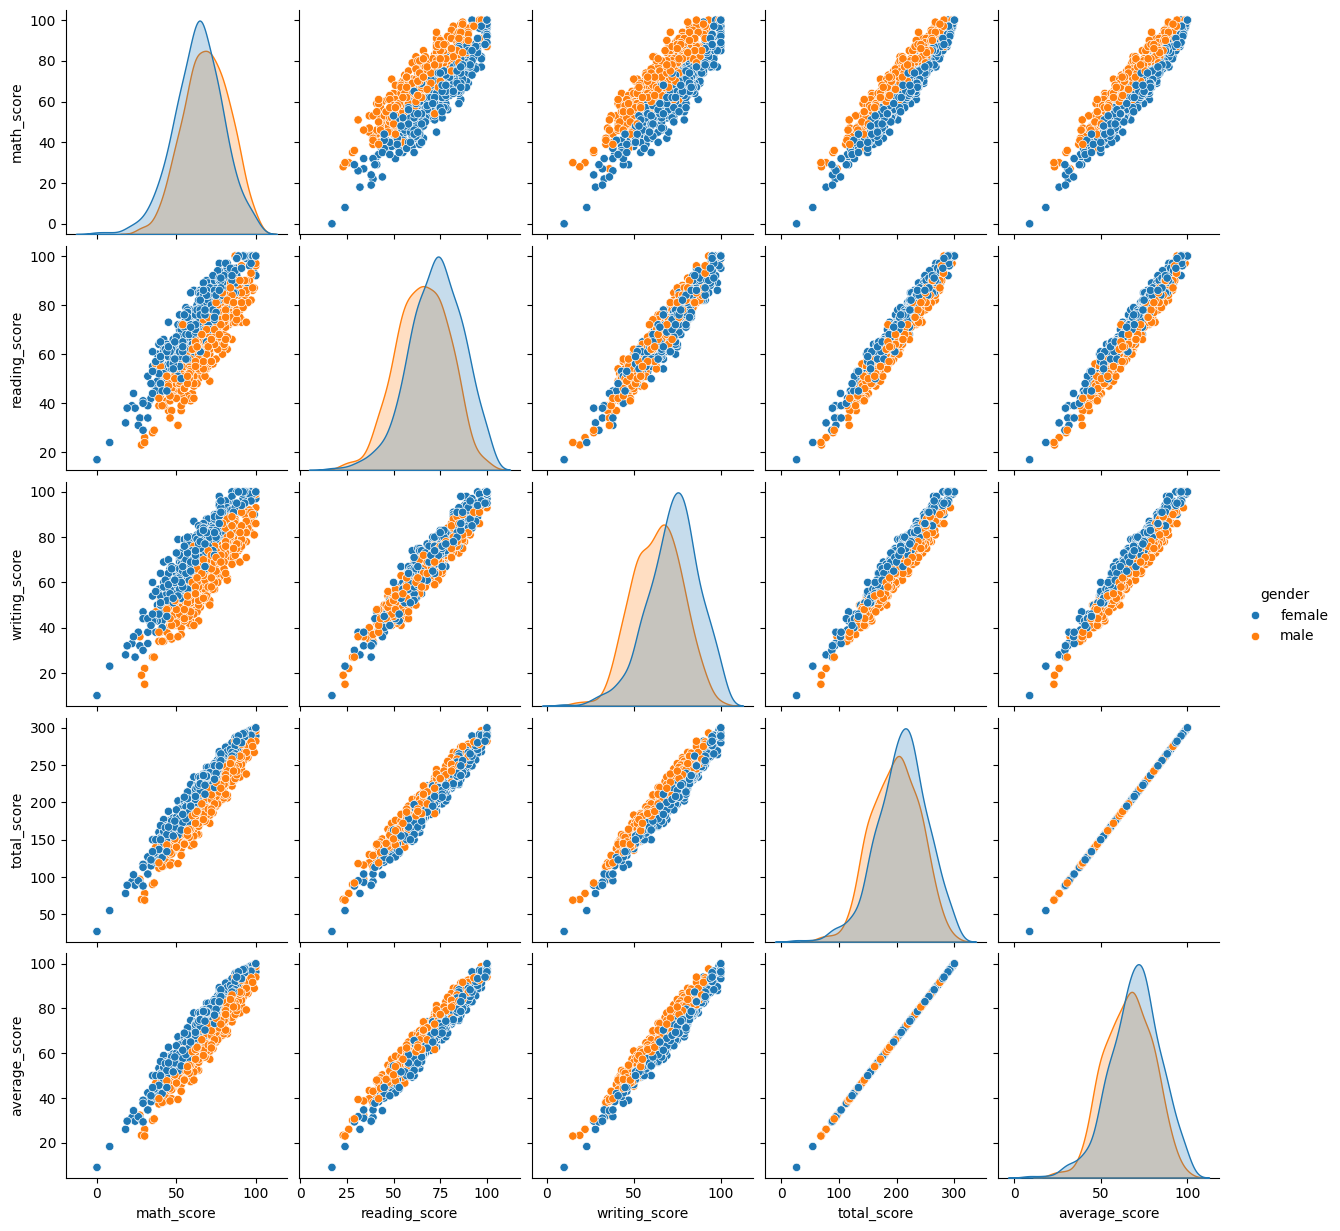

In [157]:
sns.pairplot(df,hue = 'gender')
plt.show()